# Multi Layer Perceptron classification

Classification on two normal distributions.

Implement a simple MLP using the ReLU activation function.

In [13]:
import sys
sys.path.append('..')

import numpy as np
from matplotlib import pyplot as plt

from autodiff.functions import relu, sigmoid
from autodiff.variable import Variable
from nn.losses import bce_loss
from nn.modules import Linear, Module
from nn.optimizers import SGD


class ClassificationModel(Module):
    def __init__(self, in_features, out_features):
        self.linear1 = Linear(in_features, 4)
        self.linear2 = Linear(4, out_features)

    def forward(self, x):
        y = self.linear1(x)
        y = relu(y)
        y = self.linear2(y)
        return sigmoid(y)

Generate the data from to normal distributions. The model takes as input the $(x,y)$ coordinates of each point and predicts the probability of belonging to each class.

In [14]:
n1 = np.random.multivariate_normal([-0.5, 0.5], 0.1 * np.identity(2), [100])
n2 = np.random.multivariate_normal([0.5, -0.5], 0.1 * np.identity(2), [100])
normals = np.concatenate([n1, n2])
labels = [1.] * len(n1) + [0.] * len(n2)

data_x = [Variable([x]) for x in normals]
data_y = [Variable([l]) for l in labels]

Create the model and optimizer.

In [15]:
model = ClassificationModel(2, 1)
optimizer = SGD(model.parameters(), lr=1e-2)
epochs = 100

Train the model using the binary cross entropy loss.

Epoch 0: 0.6061388080670587
Epoch 1: 0.5281492778483151
Epoch 2: 0.4520363799154303
Epoch 3: 0.3811059672211041
Epoch 4: 0.3214508391469758
Epoch 5: 0.27416518894925906
Epoch 6: 0.23792410823603663
Epoch 7: 0.209183432079118
Epoch 8: 0.1865743693880394
Epoch 9: 0.16865646653496794
Epoch 10: 0.1543931628059253
Epoch 11: 0.14308665516501082
Epoch 12: 0.13396346786985183
Epoch 13: 0.12619780506551742
Epoch 14: 0.11976770919048403
Epoch 15: 0.11420049265589642
Epoch 16: 0.10935504114375007
Epoch 17: 0.10513030349519316
Epoch 18: 0.1014326220069766
Epoch 19: 0.09818092553009254
Epoch 20: 0.09526189539655772
Epoch 21: 0.09263695768265094
Epoch 22: 0.09028115563418898
Epoch 23: 0.08815197741947689
Epoch 24: 0.08621960941058593
Epoch 25: 0.08445831296507957
Epoch 26: 0.08284681991664299
Epoch 27: 0.08136731902141527
Epoch 28: 0.08000473521013123
Epoch 29: 0.0787461985248358
Epoch 30: 0.07757252983378049
Epoch 31: 0.07647310761023314
Epoch 32: 0.07549589783569258
Epoch 33: 0.07458028848158549
E

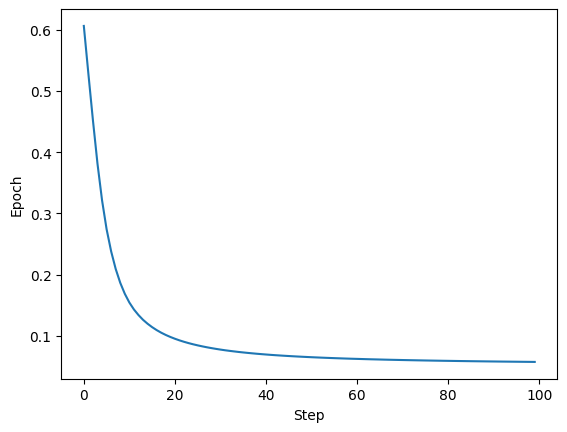

In [16]:
losses = []

for e in range(epochs):
    epoch_losses = []

    for (d, t) in zip(data_x, data_y):
        pred = model.forward(d)

        loss = bce_loss(pred, t)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_losses.append(loss.value.squeeze())

    epoch_loss = sum(epoch_losses) / len(data_x)
    print(f'Epoch {e}: {epoch_loss}')
    losses.append(epoch_loss)
pred = [model.forward(x).value for x in data_x]

plt.plot(np.arange(len(losses)), losses)
plt.xlabel('Step')
plt.ylabel('Epoch')
plt.show()

Test the model.

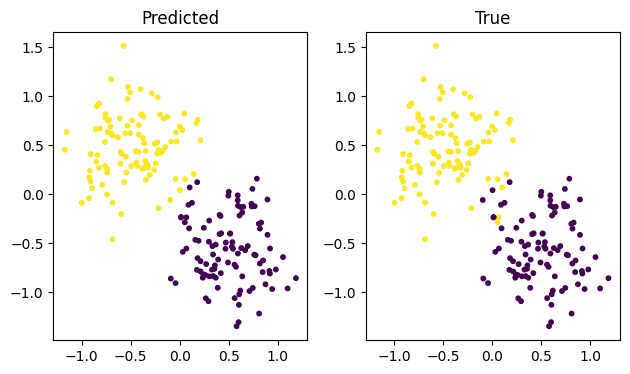

In [17]:
fig, (ax_pred, ax_true) = plt.subplots(1, 2)

x = np.concatenate(data_x)
pred = np.array(pred)

ax_pred.set_title('Predicted')
ax_pred.scatter(*x.T, c=np.astype(pred > 0.5, np.int64), s=10)
ax_pred.set_aspect('equal')

ax_true.set_title('True')
ax_true.scatter(*x.T, c=data_y, s=10)
ax_true.set_aspect('equal')

plt.tight_layout()
plt.show()

Plot the separation line between the classes.

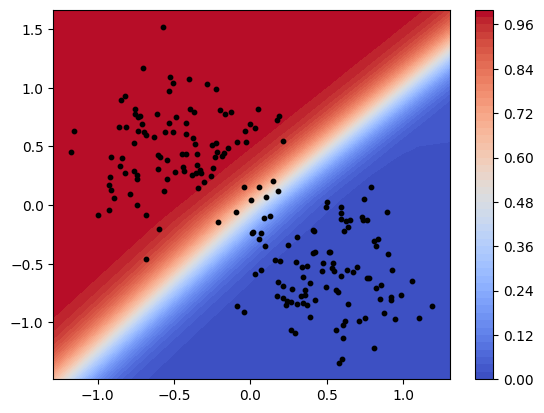

In [18]:
max_lim, min_lim = np.max(x, axis=0).flatten(), np.min(x, axis=0).flatten()
lims = list(zip(min_lim * 1.1, max_lim * 1.1))
grid_xx, grid_yy = np.meshgrid(np.linspace(*lims[0]), np.linspace(*lims[1]))
grid_x, grid_y = grid_xx.flatten(), grid_yy.flatten()
data = np.stack([grid_x, grid_y]).T
data = [Variable(d) for d in data]

pred = [model.forward(d) for d in data]

data = np.array(data)
proba = np.array(pred).reshape(grid_xx.shape)
contour = plt.contourf(grid_xx, grid_yy, proba, levels=50, vmin=0, vmax=1, cmap='coolwarm')
plt.colorbar(contour)

plt.scatter(*x.T, color='black', s=10)
plt.show()